In [1]:
import os
import json
import networkx as nx
import matplotlib.pyplot as plt

In [32]:
files = "simulation-20250811-162624UTC-n1000-m6-d5-c100"

In [ ]:
def create_node_graph_dict(directory):
    node_id_to_name = {}
    node_graph = {}
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if not os.path.isfile(filepath):
            continue
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                if 'ExAnte instance created' in line:
                    d = json.loads(line)
                    node_id_to_name[d['node_id']] = filename.removesuffix('-log.json')

                if 'Final Neighbors' in line:
                    d = json.loads(line)
                    node_graph[d['node_id']] = d.get('neighbors', [])

    return node_id_to_name, node_graph

In [34]:
def build_directed_graph(node_names, graph):
    """
    Scans all files in `directory`, extracts nodes and neighbors, and builds a NetworkX DiGraph.
    """

    G = nx.DiGraph()

    for node, neighbors in graph.items():
        node_name = node_names[node]  
        G.add_node(node_name)
        for nbr in neighbors:
            if nbr in node_names:
                nbr_name = node_names[nbr]
            else:
                nbr_name = nbr
            G.add_node(nbr_name)
            G.add_edge(node_name, nbr_name)

    return G

In [35]:
def visualize_directed_graph(G, figsize=(12, 12), with_labels=True):
    # Project to undirected for consistent layout
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=figsize)

    # Separate edges by reciprocity
    solid_edges = []  # bidirectional
    dashed_edges = []  # one-way
    for u, v in G.edges():
        if G.has_edge(v, u):
            # ensure each is drawn only once
            if (v, u) not in solid_edges:
                solid_edges.append((u, v))
        else:
            dashed_edges.append((u, v))

    # Draw nodes and labels
    nx.draw_networkx_nodes(G, pos, node_size=300)
    if with_labels:
        nx.draw_networkx_labels(G, pos)

    # Draw bidirectional edges as solid undirected
    if solid_edges:
        nx.draw_networkx_edges(
            G.to_undirected(), pos,
            edgelist=solid_edges,
            style='solid',
            arrows=False
        )
    # Draw one-way edges as dashed with arrows
    if dashed_edges:
        nx.draw_networkx_edges(
            G, pos,
            edgelist=dashed_edges,
            style='dashed',
            arrows=True
        )

    plt.title("Directed Neighbor Graph (one-way edges dashed)")
    plt.axis('off')
    plt.show()

In [36]:
nodes, graph = create_node_graph_dict(files)
G = build_directed_graph(nodes, graph)

# Analyze undirected projection for components and diameter
U = G.to_undirected()
comps = list(nx.connected_components(U))
print(f"Number of connected components: {len(comps)}")
for i, comp in enumerate(comps, 1):
    print(f"Component {i} (size {len(comp)}): {comp}")

max_component = None
max_component_size = 0
for i, comp in enumerate(comps, 1):
    if len(comp) > 1:
        subU = U.subgraph(comp)
        diam = nx.diameter(subU)
        if len(comp) > max_component_size:
            max_component_size = len(comp)
            max_component = comp

print(f"Max component size: {max_component_size}")
print(f"Max component: {max_component}")

Number of connected components: 28
Component 1 (size 696): {'node-374-log.log', 'node-542-log.log', 'node-172-log.log', 'node-81-log.log', 'node-561-log.log', 'node-341-log.log', 'node-79-log.log', 'node-611-log.log', 'node-640-log.log', 'node-209-log.log', 'node-297-log.log', 'node-502-log.log', 'node-393-log.log', 'node-235-log.log', 'node-630-log.log', 'node-271-log.log', 'node-481-log.log', 'node-78-log.log', 'node-150-log.log', 'node-605-log.log', 'node-531-log.log', 'node-32-log.log', 'node-665-log.log', 'node-166-log.log', 'node-347-log.log', 'node-147-log.log', 'node-300-log.log', 'node-435-log.log', 'node-382-log.log', 'node-119-log.log', 'node-318-log.log', 'node-4-log.log', 'node-631-log.log', 'node-386-log.log', 'node-366-log.log', 'node-303-log.log', 'node-448-log.log', 'node-213-log.log', 'node-392-log.log', 'node-458-log.log', 'node-629-log.log', 'node-237-log.log', 'node-578-log.log', 'node-658-log.log', 'node-545-log.log', 'node-131-log.log', 'node-174-log.log', 'node-

In [37]:
# from pyvis.network import Network


# net = Network(notebook=True, directed=True, cdn_resources='in_line')
# net.from_nx(max_component)

# # Optional controls
# net.show_buttons(filter_=["physics", "layout", "interaction"])
# net.show("graph.html")


In [38]:
def analyze_committee(directory):
    all_committees = {}
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if not os.path.isfile(filepath):
            continue
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                if "Committee elected" in line:
                    d = json.loads(line)
                    node_id = d["node_id"]  
                    committee = d["committee"]
                    all_committees[node_id] = [id["ID"] for id in committee]
    return all_committees

In [39]:
member_to_nodes = analyze_committee(files)

In [40]:
committee = set()
minimal_committee = 200
for k, v in member_to_nodes.items():
    print(k, len(v))
    minimal_committee = min(minimal_committee, len(v))
    for c in v:
        committee.add(c)

print(len(committee))
print(minimal_committee)

12D3KooWGkm2o1KTqvufPQpYHagNNR9TfRC54ibR9EbDEiT3kr3Z 57
12D3KooWGKDvnXT1oM81324Poyyaanag1EH54j9y6SVXgD4Youdw 57
12D3KooWPfgaJdoBvBAPwxTnQ4UmpCc9USfpzQC2Js9akQfBYhJC 57
12D3KooWDTV2B4KH2nG6Vy9WmBofEejM26ReJZiXG4fti8jptjRR 57
12D3KooWBTZpkqKLWt1u77G1r8MukHojLaajQqKdniXS6PJhoRcK 57
12D3KooWGp6inHKX4df6gFc4XMvGqD6gx9uuHfuZfUck2MZZsLAd 57
12D3KooWNWwg5nbpchQ689KtKQvjCnzLaEkRm38UrFVeymV4T3zA 57
12D3KooWSjqTK4UNTTqDX6sxDgQMM9uXhg7UmQQmK3xHub4dA3o6 57
12D3KooWLpcMcWQ1XwdAi62oUE9iVWfsiHRByApDb7VUXNnZGoUj 1
12D3KooWPeWvBM44UjcsQo1LF4nbMHf5nyABpXrPQ9MmdrhtkToH 57
12D3KooWQphp8zfvWBqEYtUy1xnCN5E4HKcKCXrnDSAxtDNwnPti 57
12D3KooWBvSWTdPk1E98DMV2dkV55Xvm6TzSEePoGub1ErnJeVrn 57
12D3KooWD9GmWxvidUUhSkNCKNs4CJSavviMMPPiLpF6gDfyFQwr 57
12D3KooWLAq2vwKsomakf9kioBxtW6F8YDDK87rvsMQqxWH3dQuq 57
12D3KooWEnL8DBNhAUpn9pWg3hRz4zYq6ovduBbrmYidFQkmKf14 57
12D3KooWFP2uLPzwu1GhjcnNwBCLSeUH7FVMx3149tj8M3cFPqXf 57
12D3KooWJcQEh5xCRUSmgmzWkATS3fqEh72fPfhB4ApiMwUqqoxL 57
12D3KooWLi697EMPuTCdLAFJnz1KDNRuPxQfUaqxvNKf2ue4H

In [41]:
# Analyze average node degree
import numpy as np

def analyze_node_degrees(G):
    """
    Analyze node degrees in both directed and undirected versions of the graph
    """
    print("=== DIRECTED GRAPH ANALYSIS ===")
    
    # In-degree analysis
    in_degrees = [G.in_degree(node) for node in G.nodes()]
    avg_in_degree = np.mean(in_degrees)
    print(f"Average in-degree: {avg_in_degree:.2f}")
    print(f"Min in-degree: {min(in_degrees)}")
    print(f"Max in-degree: {max(in_degrees)}")
    print(f"Median in-degree: {np.median(in_degrees):.2f}")
    print(f"Std dev in-degree: {np.std(in_degrees):.2f}")
    
    # Out-degree analysis
    out_degrees = [G.out_degree(node) for node in G.nodes()]
    avg_out_degree = np.mean(out_degrees)
    print(f"\nAverage out-degree: {avg_out_degree:.2f}")
    print(f"Min out-degree: {min(out_degrees)}")
    print(f"Max out-degree: {max(out_degrees)}")
    print(f"Median out-degree: {np.median(out_degrees):.2f}")
    print(f"Std dev out-degree: {np.std(out_degrees):.2f}")
    
    print("\n=== UNDIRECTED GRAPH ANALYSIS ===")
    
    # Convert to undirected for total degree analysis
    U = G.to_undirected()
    degrees = [U.degree(node) for node in U.nodes()]
    avg_degree = np.mean(degrees)
    
    print(f"Average degree: {avg_degree:.2f}")
    print(f"Min degree: {min(degrees)}")
    print(f"Max degree: {max(degrees)}")
    print(f"Median degree: {np.median(degrees):.2f}")
    print(f"Std dev degree: {np.std(degrees):.2f}")
    
    print(f"\nTotal nodes: {G.number_of_nodes()}")
    print(f"Total edges (directed): {G.number_of_edges()}")
    print(f"Total edges (undirected): {U.number_of_edges()}")
    
    return {
        'in_degrees': in_degrees,
        'out_degrees': out_degrees,
        'degrees': degrees,
        'avg_in_degree': avg_in_degree,
        'avg_out_degree': avg_out_degree,
        'avg_degree': avg_degree
    }

# Analyze the graph
degree_stats = analyze_node_degrees(G)


=== DIRECTED GRAPH ANALYSIS ===
Average in-degree: 10.79
Min in-degree: 0
Max in-degree: 61
Median in-degree: 6.00
Std dev in-degree: 13.97

Average out-degree: 10.79
Min out-degree: 0
Max out-degree: 63
Median out-degree: 6.00
Std dev out-degree: 14.44

=== UNDIRECTED GRAPH ANALYSIS ===
Average degree: 11.06
Min degree: 0
Max degree: 63
Median degree: 6.00
Std dev degree: 14.42

Total nodes: 723
Total edges (directed): 7804
Total edges (undirected): 3999


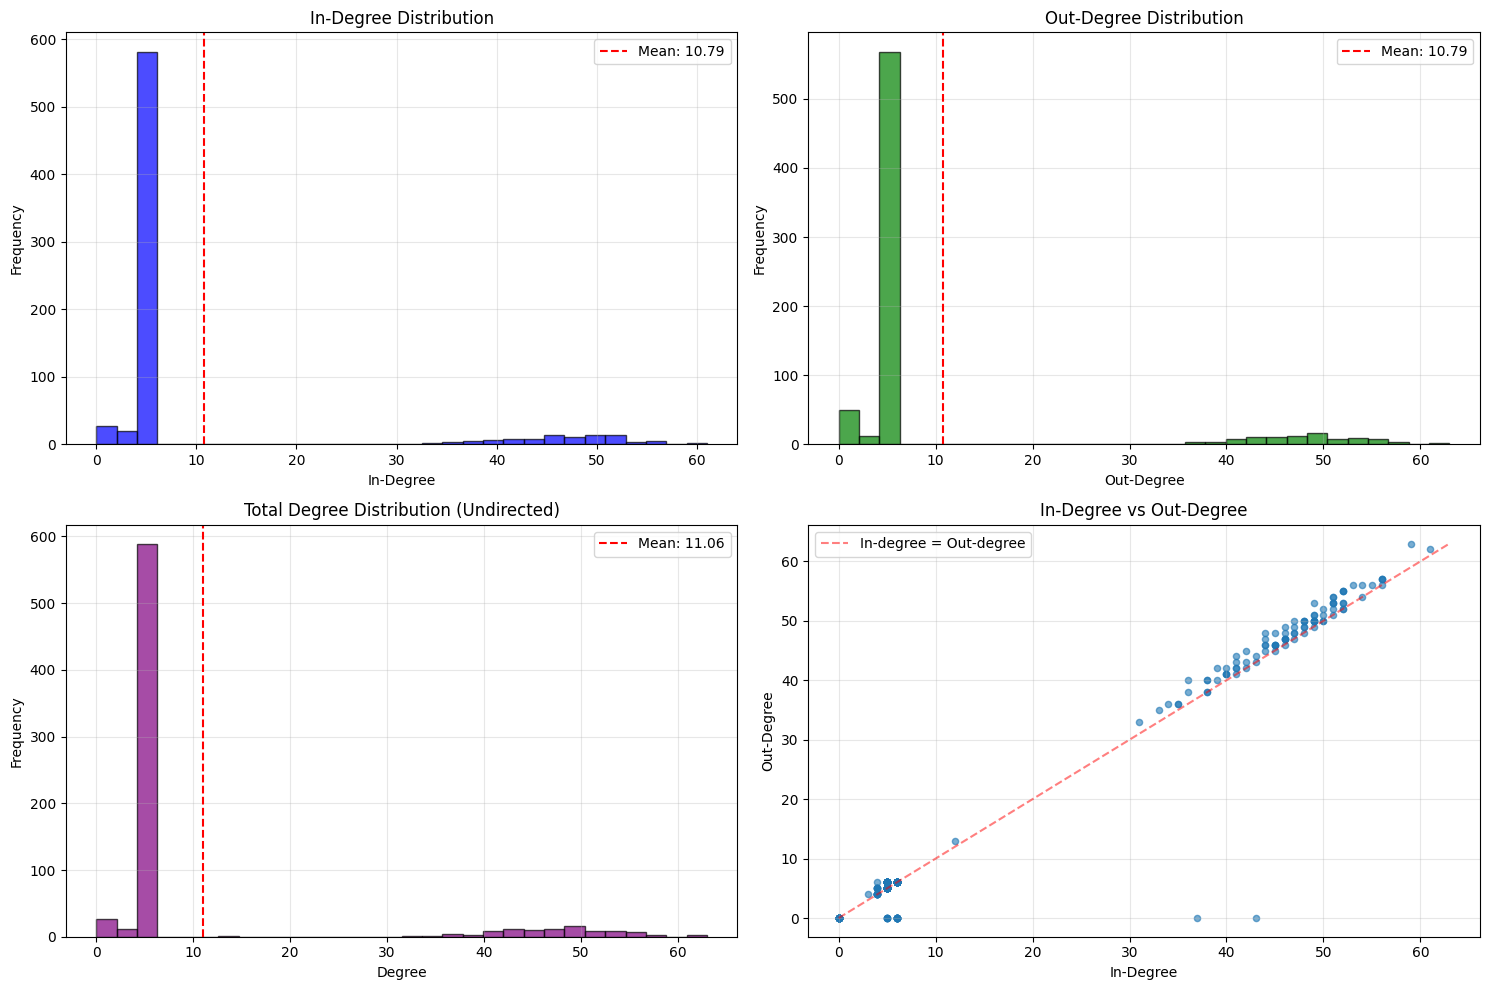

In [42]:
# Visualize degree distributions
def plot_degree_distributions(degree_stats):
    """
    Create histograms showing the distribution of node degrees
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # In-degree distribution
    axes[0, 0].hist(degree_stats['in_degrees'], bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[0, 0].axvline(degree_stats['avg_in_degree'], color='red', linestyle='--', 
                       label=f'Mean: {degree_stats["avg_in_degree"]:.2f}')
    axes[0, 0].set_title('In-Degree Distribution')
    axes[0, 0].set_xlabel('In-Degree')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Out-degree distribution
    axes[0, 1].hist(degree_stats['out_degrees'], bins=30, alpha=0.7, color='green', edgecolor='black')
    axes[0, 1].axvline(degree_stats['avg_out_degree'], color='red', linestyle='--', 
                       label=f'Mean: {degree_stats["avg_out_degree"]:.2f}')
    axes[0, 1].set_title('Out-Degree Distribution')
    axes[0, 1].set_xlabel('Out-Degree')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Total degree distribution (undirected)
    axes[1, 0].hist(degree_stats['degrees'], bins=30, alpha=0.7, color='purple', edgecolor='black')
    axes[1, 0].axvline(degree_stats['avg_degree'], color='red', linestyle='--', 
                       label=f'Mean: {degree_stats["avg_degree"]:.2f}')
    axes[1, 0].set_title('Total Degree Distribution (Undirected)')
    axes[1, 0].set_xlabel('Degree')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Degree comparison plot
    axes[1, 1].scatter(degree_stats['in_degrees'], degree_stats['out_degrees'], alpha=0.6, s=20)
    axes[1, 1].set_title('In-Degree vs Out-Degree')
    axes[1, 1].set_xlabel('In-Degree')
    axes[1, 1].set_ylabel('Out-Degree')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Add diagonal line for reference
    max_degree = max(max(degree_stats['in_degrees']), max(degree_stats['out_degrees']))
    axes[1, 1].plot([0, max_degree], [0, max_degree], 'r--', alpha=0.5, label='In-degree = Out-degree')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()

# Create the visualizations
plot_degree_distributions(degree_stats)


In [43]:
# Additional statistical analysis
def detailed_degree_analysis(G, degree_stats):
    """
    Provide detailed statistical analysis of node degrees
    """
    U = G.to_undirected()
    
    print("=== DETAILED DEGREE STATISTICS ===")
    
    # Network density
    directed_density = nx.density(G)
    undirected_density = nx.density(U)
    
    print(f"Network density (directed): {directed_density:.4f}")
    print(f"Network density (undirected): {undirected_density:.4f}")
    
    # Degree centrality statistics
    in_degree_centrality = list(nx.in_degree_centrality(G).values())
    out_degree_centrality = list(nx.out_degree_centrality(G).values())
    degree_centrality = list(nx.degree_centrality(U).values())
    
    print(f"\nDegree Centrality Statistics:")
    print(f"Average in-degree centrality: {np.mean(in_degree_centrality):.4f}")
    print(f"Average out-degree centrality: {np.mean(out_degree_centrality):.4f}")
    print(f"Average degree centrality (undirected): {np.mean(degree_centrality):.4f}")
    
    # Percentile analysis
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    
    print(f"\n=== DEGREE PERCENTILES ===")
    print("Percentile | In-Degree | Out-Degree | Total Degree")
    print("-" * 50)
    for p in percentiles:
        in_p = np.percentile(degree_stats['in_degrees'], p)
        out_p = np.percentile(degree_stats['out_degrees'], p)
        total_p = np.percentile(degree_stats['degrees'], p)
        print(f"{p:>9}% | {in_p:>9.1f} | {out_p:>10.1f} | {total_p:>12.1f}")
    
    # Nodes with extreme degrees
    max_in_degree = max(degree_stats['in_degrees'])
    max_out_degree = max(degree_stats['out_degrees'])
    max_total_degree = max(degree_stats['degrees'])
    
    # Find nodes with maximum degrees
    max_in_nodes = [node for node in G.nodes() if G.in_degree(node) == max_in_degree]
    max_out_nodes = [node for node in G.nodes() if G.out_degree(node) == max_out_degree]
    max_total_nodes = [node for node in U.nodes() if U.degree(node) == max_total_degree]
    
    print(f"\n=== NODES WITH EXTREME DEGREES ===")
    print(f"Nodes with highest in-degree ({max_in_degree}): {max_in_nodes[:5]}")  # Show first 5
    print(f"Nodes with highest out-degree ({max_out_degree}): {max_out_nodes[:5]}")
    print(f"Nodes with highest total degree ({max_total_degree}): {max_total_nodes[:5]}")
    
    # Degree correlation
    correlation = np.corrcoef(degree_stats['in_degrees'], degree_stats['out_degrees'])[0, 1]
    print(f"\nCorrelation between in-degree and out-degree: {correlation:.4f}")
    
    return {
        'directed_density': directed_density,
        'undirected_density': undirected_density,
        'degree_correlation': correlation,
        'max_in_nodes': max_in_nodes,
        'max_out_nodes': max_out_nodes,
        'max_total_nodes': max_total_nodes
    }

# Perform detailed analysis
detailed_stats = detailed_degree_analysis(G, degree_stats)


=== DETAILED DEGREE STATISTICS ===
Network density (directed): 0.0150
Network density (undirected): 0.0153

Degree Centrality Statistics:
Average in-degree centrality: 0.0150
Average out-degree centrality: 0.0150
Average degree centrality (undirected): 0.0153

=== DEGREE PERCENTILES ===
Percentile | In-Degree | Out-Degree | Total Degree
--------------------------------------------------
       10% |       5.0 |        5.0 |          5.0
       25% |       5.0 |        6.0 |          6.0
       50% |       6.0 |        6.0 |          6.0
       75% |       6.0 |        6.0 |          6.0
       90% |      41.0 |       42.0 |         42.8
       95% |      48.9 |       50.0 |         50.0
       99% |      54.0 |       56.0 |         56.0

=== NODES WITH EXTREME DEGREES ===
Nodes with highest in-degree (61): ['node-17-log.log']
Nodes with highest out-degree (63): ['node-80-log.log']
Nodes with highest total degree (63): ['node-80-log.log']

Correlation between in-degree and out-degree: 0